**STAT 426: Homework-4**
- **UID: 206547205**
- **Name: Hochan Son**
- **Email: hochanson@g.ucla.edu**

## Problem 1: Transformers for Single & Multi-Step Forecasting

In this assignment, you will implement Transformer architectures to predict air pollution levels using the Beijing Multi-Site Air Quality Data Set (use only the Aotizhongxin station data).

- **Preprocessing:** As in previous assignments, use the first 80% of data for training, 10% for
validation, and 10% for testing. Impute missing values, apply cyclical feature encoding to the
wind direction, and normalize your continuous features. Use a historical window of T = 24 hours.

- **Part (a):** Single-Step Forecasting (t + 1) [20 Points]
First, we will predict just the next hour’s PM2.5 concentration using two different models.

## Part 0: Setup & Preprocessing (same as HW3)

We reuse the exact preprocessing pipeline from HW3 for a fair comparison.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, time, warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

/opt/anaconda3/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: mps


In [2]:
# ---------- Load & clean data (identical to HW3) ----------
df = pd.read_csv('../HW3/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df_processed = df.copy()

numeric_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
df_processed[numeric_cols] = df_processed[numeric_cols].interpolate(method='linear', limit_direction='both')
df_processed['wd'] = df_processed['wd'].fillna(df_processed['wd'].mode()[0])

# Cyclical wind direction encoding
wind_map = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
            'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}
df_processed['wd_rad'] = df_processed['wd'].map(wind_map) * np.pi / 180
df_processed['wd_sin'] = np.sin(df_processed['wd_rad'])
df_processed['wd_cos'] = np.cos(df_processed['wd_rad'])

feature_columns = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM','wd_sin','wd_cos']
data = df_processed[feature_columns].values
data = np.nan_to_num(data, nan=0.0)

print(f'Feature matrix: {data.shape}  ({len(feature_columns)} features)')

Feature matrix: (35064, 13)  (13 features)


In [3]:
# ---------- Chronological split & normalization ----------
n = len(data)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(data[:train_end])
val_scaled   = scaler.transform(data[train_end:val_end])
test_scaled  = scaler.transform(data[val_end:])

print(f'Train {train_scaled.shape}  Val {val_scaled.shape}  Test {test_scaled.shape}')

Train (28051, 13)  Val (3506, 13)  Test (3507, 13)


In [4]:
# ---------- Sliding-window dataset for single-step (Part a) ----------
PM25_IDX    = 0
WINDOW_SIZE = 24
BATCH_SIZE  = 64

def create_windows(data, target_idx, window):
    """Create sliding windows for single-step forecasting (predict t+1)."""
    n = len(data) - window
    X = np.zeros((n, window, data.shape[1]))
    y = np.zeros(n)
    for i in range(n):
        X[i] = data[i:i+window]
        y[i] = data[i+window, target_idx]
    return X, y

X_train, y_train = create_windows(train_scaled, PM25_IDX, WINDOW_SIZE)
X_val,   y_val   = create_windows(val_scaled,   PM25_IDX, WINDOW_SIZE)
X_test,  y_test  = create_windows(test_scaled,  PM25_IDX, WINDOW_SIZE)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val)),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test)),
                          batch_size=BATCH_SIZE)

INPUT_DIM = X_train.shape[2]   # 13
print(f'Samples  -> Train {len(X_train)}  Val {len(X_val)}  Test {len(X_test)}')
print(f'Each sample: ({WINDOW_SIZE}, {INPUT_DIM}) -> 1 scalar')

Samples  -> Train 28027  Val 3482  Test 3483
Each sample: (24, 13) -> 1 scalar


In [5]:
# ---------- Metric helpers ----------
def calc_metrics(y_true, y_pred, scaler=None, idx=0):
    """RMSE & MAE, optionally in original scale."""
    if scaler is not None:
        d = np.zeros((len(y_true), scaler.scale_.shape[0]))
        d[:, idx] = y_true
        y_true = scaler.inverse_transform(d)[:, idx]
        d[:, idx] = y_pred
        y_pred = scaler.inverse_transform(d)[:, idx]
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae  = np.mean(np.abs(y_true - y_pred))
    return rmse, mae

---
## Part (a): Single-Step Forecasting (t+1) [20 Points]

### Step 1 -- Baseline Models (from HW3)

The HW asks you to retrieve your best LSTM and GRU test RMSE/MAE from HW3. You do **not** need to retrain them. Simply fill in your numbers below.

In [6]:
# ============================================================
# TODO: Fill in YOUR best LSTM and GRU results from HW3
# ============================================================
hw3_lstm_rmse=21.9758   # e.g., 21.43
hw3_lstm_mae=13.2575   # e.g., 11.72
hw3_gru_rmse=21.8550   # e.g., 22.74
hw3_gru_mae=12.5847   # e.g., 13.03

print('HW3 Baseline Results (replace with your own):')
print(f'  LSTM -> RMSE: {hw3_lstm_rmse}, MAE: {hw3_lstm_mae}')
print(f'  GRU  -> RMSE: {hw3_gru_rmse},  MAE: {hw3_gru_mae}')

HW3 Baseline Results (replace with your own):
  LSTM -> RMSE: 21.9758, MAE: 13.2575
  GRU  -> RMSE: 21.855,  MAE: 12.5847


### Step 2 -- Positional Encoding

Transformers have no built-in notion of sequence order. We inject position information using **sinusoidal positional encoding** ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)):

$$PE_{(pos, 2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \qquad PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Each dimension oscillates at a different frequency, giving the model a unique "fingerprint" for each position.

In [7]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).
    Added to input embeddings so the model knows token order.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)                          # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()    # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)   # even indices
        pe[:, 1::2] = torch.cos(position * div_term)   # odd indices
        pe = pe.unsqueeze(0)                            # (1, max_len, d_model)
        self.register_buffer('pe', pe)                  # not a learnable parameter

    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

### Step 3 -- Encoder-Only Transformer

For single-step forecasting we use an **encoder-only** architecture (like BERT):

1. **Input projection**: Linear layer from 13 raw features to `d_model=64`
2. **Positional encoding**: Sinusoidal PE added to projected embeddings
3. **`nn.TransformerEncoder`**: 2 encoder layers, 4 attention heads
4. **Regression head**: Take the **last time step's** output `output[:, -1, :]` and project to a scalar

Note: the HW specifies using the **final time step** representation (not mean pooling).

In [8]:
class TransformerForecaster(nn.Module):
    """
    Encoder-only Transformer for single-step time-series forecasting.

    Architecture:
        input (B, T=24, 13)
          -> Linear projection to d_model
          -> Positional Encoding
          -> nn.TransformerEncoder (N layers)
          -> Take last time step: output[:, -1, :]
          -> Linear head -> scalar prediction
    """
    def __init__(self, n_features, d_model=64, n_heads=4, d_ff=128,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True     # so input shape is (B, T, d_model)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out  = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch, seq_len=24, n_features=13)
        returns: (batch,) predicted PM2.5 at t+1
        """
        x = self.input_proj(x)       # (B, T, d_model)
        x = self.pos_enc(x)          # (B, T, d_model) + positional info
        x = self.encoder(x)          # (B, T, d_model)

        # Use the LAST time step's representation
        x = x[:, -1, :]              # (B, d_model)
        out = self.fc_out(x).squeeze(-1)  # (B,)
        return out

In [9]:
# Instantiate and inspect
encoder_model = TransformerForecaster(
    n_features=INPUT_DIM, d_model=64, n_heads=4, d_ff=128, n_layers=2, dropout=0.1
).to(device)

n_params = sum(p.numel() for p in encoder_model.parameters())
print(f'Encoder-Only Transformer')
print(f'  d_model=64, heads=4, FFN=128, layers=2')
print(f'  Total parameters: {n_params:,}')
print()
print(encoder_model)

Encoder-Only Transformer
  d_model=64, heads=4, FFN=128, layers=2
  Total parameters: 67,905

TransformerForecaster(
  (input_proj): Linear(in_features=13, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=64, 

### Step 4 -- Training

We train with MSE loss, Adam optimizer, and early stopping -- identical to HW3.

In [10]:
def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3, patience=7):
    """
    Train with early stopping. Works with models that return either a tensor
    or a tuple (pred, extras).
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        t0 = time.time()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx)
            preds = out[0] if isinstance(out, tuple) else out
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * bx.size(0)
        epoch_time = time.time() - t0
        train_loss /= len(train_loader.dataset)

        # --- Val ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                out = model(bx)
                preds = out[0] if isinstance(out, tuple) else out
                loss = criterion(preds, by)
                val_loss += loss.item() * bx.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:2d}/{num_epochs}]  '
                  f'Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}  ({epoch_time:.2f}s)')

        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f'Best val loss: {best_val_loss:.6f}')
    return history

In [11]:
torch.manual_seed(42)
encoder_model = TransformerForecaster(
    n_features=INPUT_DIM, d_model=64, n_heads=4, d_ff=128, n_layers=2, dropout=0.1
).to(device)

print(f'Training Encoder-Only Transformer ({sum(p.numel() for p in encoder_model.parameters()):,} params)')
print('=' * 70)

enc_history = train_model(encoder_model, train_loader, val_loader,
                          num_epochs=50, lr=1e-3, patience=7)

Training Encoder-Only Transformer (67,905 params)


Epoch [ 1/50]  Train Loss: 0.114969  Val Loss: 0.030326  (6.82s)


Epoch [ 5/50]  Train Loss: 0.068284  Val Loss: 0.035317  (6.21s)


Epoch [10/50]  Train Loss: 0.063155  Val Loss: 0.027770  (6.22s)


Epoch [15/50]  Train Loss: 0.057358  Val Loss: 0.023078  (6.31s)



Early stopping at epoch 16
Best val loss: 0.022719


### Training Curves

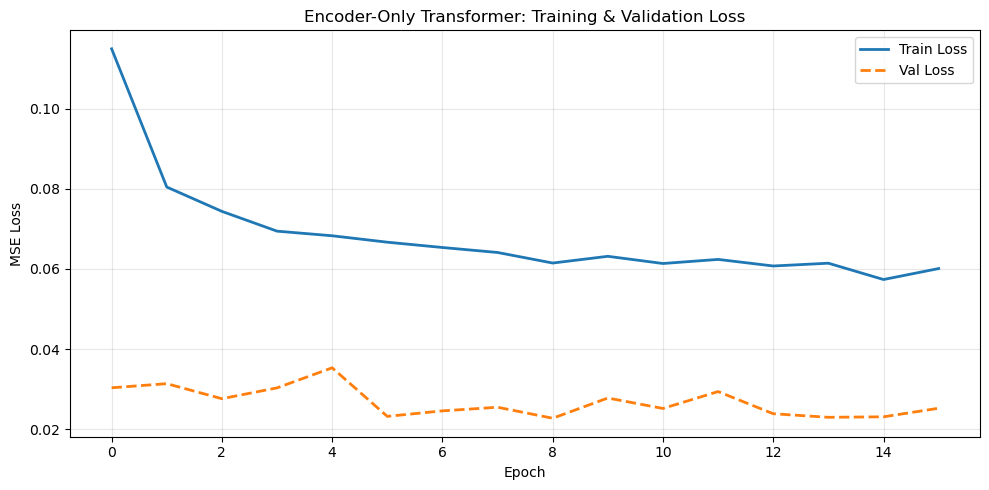

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(enc_history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(enc_history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Encoder-Only Transformer: Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5 -- Test Evaluation & Comparison

In [13]:
# Evaluate Encoder-Only Transformer on test set
encoder_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        out = encoder_model(bx)
        preds = out[0] if isinstance(out, tuple) else out
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(by.numpy())

enc_preds   = np.array(all_preds)
enc_targets = np.array(all_targets)

enc_rmse, enc_mae = calc_metrics(enc_targets, enc_preds, scaler, PM25_IDX)

print(f'Encoder-Only Transformer (Test Set):')
print(f'  RMSE: {enc_rmse:.2f} ug/m3,  MAE: {enc_mae:.2f} ug/m3')
print()
print(f'HW3 Baselines (fill in your own):')
print(f'  LSTM -> RMSE: {hw3_lstm_rmse}, MAE: {hw3_lstm_mae}')
print(f'  GRU  -> RMSE: {hw3_gru_rmse},  MAE: {hw3_gru_mae}')

Encoder-Only Transformer (Test Set):
  RMSE: 23.24 ug/m3,  MAE: 13.18 ug/m3

HW3 Baselines (fill in your own):
  LSTM -> RMSE: 21.9758, MAE: 13.2575
  GRU  -> RMSE: 21.855,  MAE: 12.5847


### Predicted vs. Actual (200-hour window)

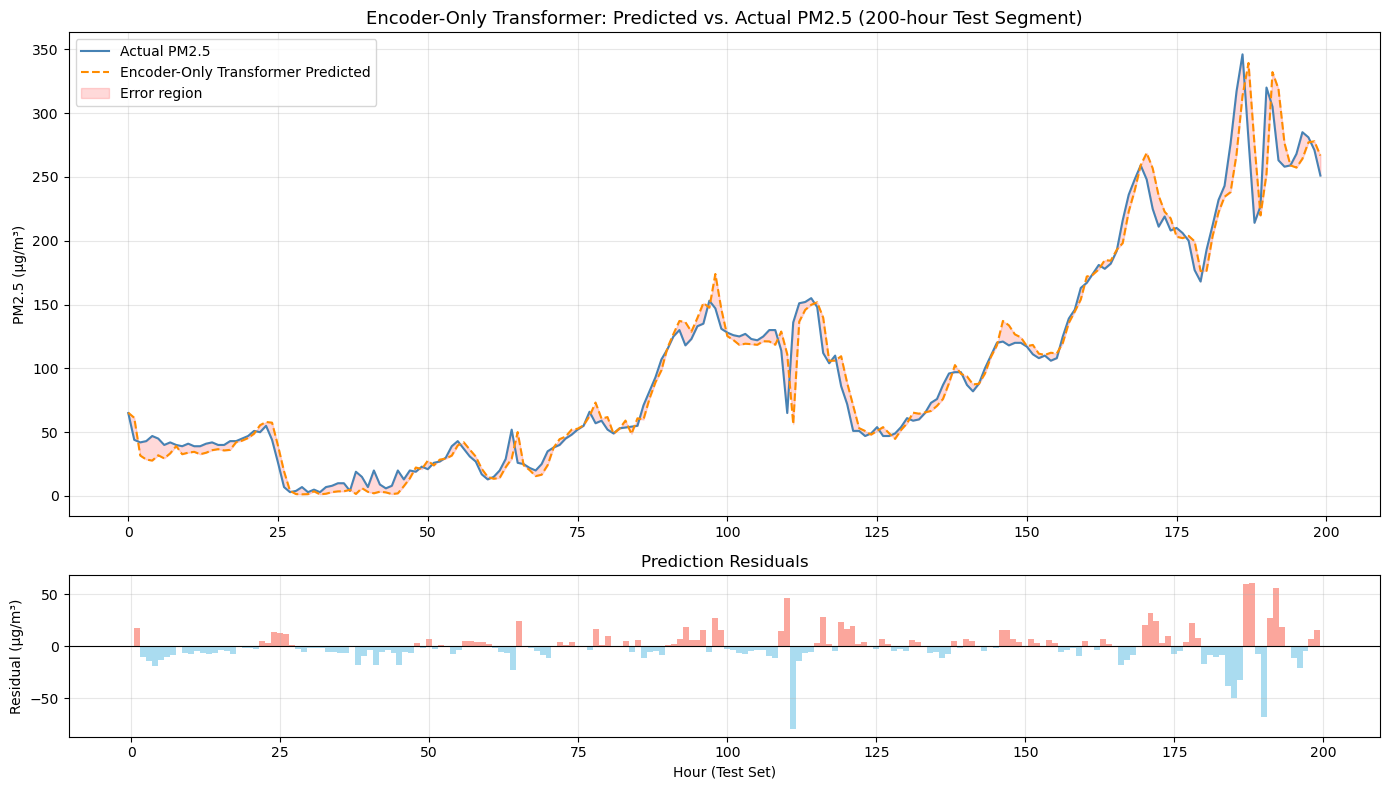

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# ── Step 1: Collect predictions from best model (Encoder-Only Transformer) ────────────────────────
n_f = scaler.scale_.shape[0]
d = np.zeros((len(enc_preds), n_f)); d[:, PM25_IDX] = enc_preds
preds_orig = scaler.inverse_transform(d)[:, PM25_IDX]
d[:, PM25_IDX] = enc_targets
targets_orig = scaler.inverse_transform(d)[:, PM25_IDX]
# ── Step 2: Inverse transform to original PM2.5 scale ─────────────────────────
# ── Step 3: Plot 200-hour segment ─────────────────────────────────────────────
start, end = 0, 200
hours = range(start, end)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(hours, targets_orig[start:end], label='Actual PM2.5',   color='steelblue',  linewidth=1.5)
axes[0].plot(hours, preds_orig[start:end],   label='Encoder-Only Transformer Predicted', color='darkorange', linewidth=1.5, linestyle='--')
axes[0].fill_between(hours, targets_orig[start:end], preds_orig[start:end],
                     alpha=0.15, color='red', label='Error region')
axes[0].set_title('Encoder-Only Transformer: Predicted vs. Actual PM2.5 (200-hour Test Segment)', fontsize=13)
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
error = preds_orig[start:end] - targets_orig[start:end]
axes[1].bar(hours, error, color=np.where(error > 0, 'salmon', 'skyblue'), alpha=0.7, width=1.0)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Hour (Test Set)')
axes[1].set_ylabel('Residual (μg/m³)')
axes[1].set_title('Prediction Residuals')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Part (b): Multi-Step Forecasting (t+1, t+2, t+3) [30 Points]

Now we modify the task to predict the **next 3 hours** of PM2.5. This requires a full **Encoder-Decoder Transformer**.

Before we build it, let's understand the architecture in detail.

### The Full Transformer Architecture ("Attention Is All You Need")

The diagram below reproduces the original architecture from [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762). In Part (a) we only used the **left half** (Encoder). Now we need **both halves**.

```
                        ┌─────────────────────────────────────────────────────────┐
                        │              THE  TRANSFORMER                           │
                        │                                                         │
   ENCODER (left)       │                           DECODER (right)               │
                        │                                                         │
   ┌───────────────┐    │    ┌──────────────────────────────────────────┐          │
   │ Input Embedding│    │    │ Output Embedding (shifted right)         │          │
   │ + Positional   │    │    │ + Positional Encoding                   │          │
   │   Encoding     │    │    └──────────┬─────────────────────────────┘          │
   └──────┬────────┘    │               │                                         │
          │             │               ▼                                         │
   ┌──────▼────────┐    │    ┌─────────────────────┐                              │
   │  Multi-Head    │    │    │  MASKED Multi-Head   │  ◄── Causal mask            │
   │  Self-Attention│    │    │  Self-Attention       │      (can't look ahead)     │
   │  + Add & Norm  │    │    │  + Add & Norm         │                              │
   └──────┬────────┘    │    └──────────┬────────────┘                              │
          │             │               │                                         │
   ┌──────▼────────┐    │    ┌──────────▼────────────┐                              │
   │  Feed-Forward  │    │    │  Multi-Head            │                              │
   │  Network       │    │    │  CROSS-ATTENTION       │                              │
   │  + Add & Norm  │    │    │  + Add & Norm          │                              │
   └──────┬────────┘    │    │                        │                              │
          │             │    │  Q = from decoder       │                              │
          │  ╔══════════╪════╡  K = from encoder  ◄────╪── "memory"                  │
          ╚══╣ memory   │    │  V = from encoder       │                              │
             ╚══════════╪════╡                        │                              │
                        │    └──────────┬────────────┘                              │
                        │    ┌──────────▼────────────┐                              │
                        │    │  Feed-Forward          │                              │
                        │    │  Network               │                              │
                        │    │  + Add & Norm          │                              │
                        │    └──────────┬────────────┘                              │
                        │               │                                         │
                        │    ┌──────────▼────────────┐                              │
                        │    │  Linear + Output       │                              │
                        │    └───────────────────────┘                              │
                        └─────────────────────────────────────────────────────────┘
```

**Each decoder layer has THREE sub-layers** (compared to two in the encoder):

| # | Sub-layer | What it does |
|---|-----------|-------------|
| 1 | **Masked Self-Attention** | Decoder attends to its own previous positions (with causal mask) |
| 2 | **Cross-Attention** | Decoder queries the encoder's output (memory). Q from decoder, K and V from encoder. |
| 3 | **Feed-Forward Network** | Same position-wise FFN as in the encoder |

This is identical to the original paper. PyTorch's `nn.Transformer` implements exactly this structure.

### Causal Masking: Why the Decoder Can't Look Ahead

In the encoder, self-attention is **bidirectional** -- every position can attend to every other position. This is fine because the encoder processes known historical data.

But the decoder is generating **future** values. When predicting y_{t+2}, it should only have access to y_{t+1} (and earlier), **not** y_{t+3}. Without a mask, the attention mechanism would let the decoder "cheat" by looking at future values it's supposed to predict.

The **causal mask** (also called "subsequent mask" or "look-ahead mask") enforces this constraint. It is an upper-triangular matrix of `-inf` values that, when added to the raw attention scores before softmax, zeros out the attention to future positions:

```
For our 3-step decoder (predicting t+1, t+2, t+3):

                        Keys
                   pos 0   pos 1   pos 2
              ┌──────────────────────────┐
    pos 0     │   0      -inf    -inf    │   Position 0 can only see itself
Q   pos 1     │   0       0      -inf    │   Position 1 can see 0 and itself
    pos 2     │   0       0       0      │   Position 2 can see everything up to itself
              └──────────────────────────┘

After softmax, -inf becomes 0 (no attention), 0 becomes a positive weight.
```

This ensures the decoder is truly **autoregressive**: each prediction depends only on past outputs, never on future ones.

Let's visualize this with actual code.

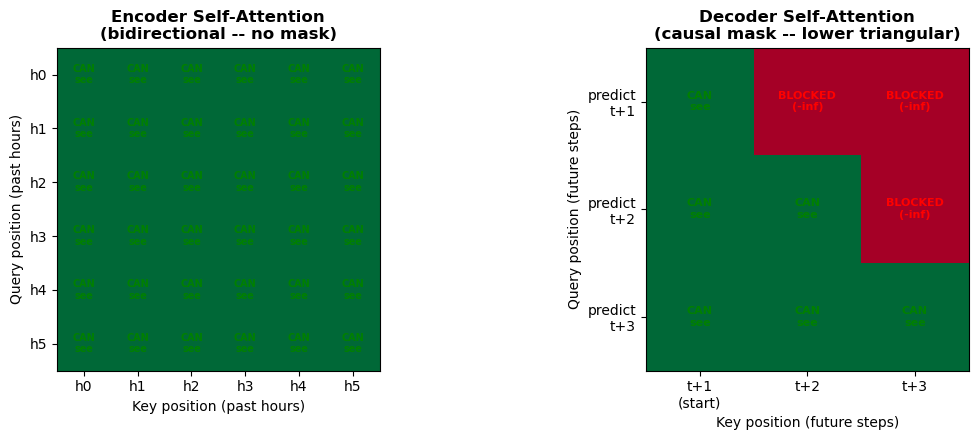

PyTorch causal mask (generate_square_subsequent_mask(3)):
tensor([[0., -inf, -inf],
        [0., 0., -inf],
        [0., 0., 0.]])

0    = attend freely
-inf = blocked (becomes 0 weight after softmax)


In [15]:
# ---- Visualize: Encoder (no mask) vs. Decoder (causal mask) ----

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Encoder self-attention (no mask -- all positions attend to all)
seq_len_enc = 6  # show 6 positions for clarity
enc_mask = np.zeros((seq_len_enc, seq_len_enc))
im0 = axes[0].imshow(enc_mask, cmap='RdYlGn', vmin=-1, vmax=0)
for i in range(seq_len_enc):
    for j in range(seq_len_enc):
        axes[0].text(j, i, 'CAN\nsee', ha='center', va='center', fontsize=7, fontweight='bold', color='green')
axes[0].set_title('Encoder Self-Attention\n(bidirectional -- no mask)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Key position (past hours)')
axes[0].set_ylabel('Query position (past hours)')
axes[0].set_xticks(range(seq_len_enc))
axes[0].set_yticks(range(seq_len_enc))
axes[0].set_xticklabels([f'h{i}' for i in range(seq_len_enc)])
axes[0].set_yticklabels([f'h{i}' for i in range(seq_len_enc)])

# Right: Decoder self-attention (causal mask -- lower triangular only)
seq_len_dec = 3  # our forecast horizon
dec_mask = np.zeros((seq_len_dec, seq_len_dec))
for i in range(seq_len_dec):
    for j in range(seq_len_dec):
        if j <= i:
            dec_mask[i, j] = 0    # allowed
            axes[1].text(j, i, 'CAN\nsee', ha='center', va='center', fontsize=8, fontweight='bold', color='green')
        else:
            dec_mask[i, j] = -1   # blocked
            axes[1].text(j, i, 'BLOCKED\n(-inf)', ha='center', va='center', fontsize=8, fontweight='bold', color='red')

im1 = axes[1].imshow(dec_mask, cmap='RdYlGn', vmin=-1, vmax=0)
axes[1].set_title('Decoder Self-Attention\n(causal mask -- lower triangular)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Key position (future steps)')
axes[1].set_ylabel('Query position (future steps)')
axes[1].set_xticks(range(seq_len_dec))
axes[1].set_yticks(range(seq_len_dec))
axes[1].set_xticklabels(['t+1\n(start)', 't+2', 't+3'])
axes[1].set_yticklabels(['predict\nt+1', 'predict\nt+2', 'predict\nt+3'])

plt.tight_layout()
plt.show()

# Also show the actual PyTorch mask
mask = nn.Transformer.generate_square_subsequent_mask(3)
print('PyTorch causal mask (generate_square_subsequent_mask(3)):')
print(mask)
print()
print('0    = attend freely')
print('-inf = blocked (becomes 0 weight after softmax)')

### What Flows from Encoder to Decoder (and Why)

A critical question: **what exactly does the decoder receive from the encoder?**

The encoder processes our 24-hour historical window and produces an output matrix of shape `(B, 24, d_model)`. This is called the **memory**. It is a rich, context-aware representation of the past -- each of the 24 positions has been refined through self-attention so it "knows about" all other positions.

This **entire memory matrix** is passed to **every decoder layer's cross-attention** sub-layer. Here's what happens inside cross-attention:

```
Cross-Attention in each decoder layer:

   Decoder hidden state          Encoder memory (24 positions)
   after masked self-attn        ┌──────────────────────────┐
   ┌───────────────┐             │ h1  h2  h3  ...  h23 h24 │
   │ pred_t+1      │──── Q ──►  │                          │
   │ pred_t+2      │             │  These become K and V    │
   │ pred_t+3      │             └──────────────────────────┘
   └───────────────┘                        │
                                       K and V
                                            │
                              ┌─────────────▼──────────────┐
                              │   Attention(Q, K, V)        │
                              │                             │
                              │   Each decoder position     │
                              │   asks: "Which of the 24    │
                              │   past hours are most       │
                              │   relevant to what I'm      │
                              │   predicting right now?"    │
                              └─────────────────────────────┘
```

**Concrete example for our task:**
- When predicting **y_{t+1}** (next hour's PM2.5), the decoder might attend heavily to the most recent hours (h23, h24) and to hours with similar weather patterns.
- When predicting **y_{t+3}** (three hours out), the decoder might spread attention more broadly, looking for longer-term trends.

**Why send the full memory (not just the last position)?**
If we only passed the encoder's final hidden state (like a seq2seq RNN), the decoder would have a single compressed vector to work from -- a bottleneck. By passing all 24 encoder positions, cross-attention can selectively retrieve fine-grained information from any point in the historical window. This is one of the Transformer's key advantages over RNN-based encoder-decoder models.

**Note on cross-attention vs. self-attention masks:** Cross-attention has **no mask** by default. The decoder is allowed to attend to all 24 encoder positions freely -- only the decoder's self-attention needs the causal mask. This makes sense: the encoder represents the *past*, which is fully known.

### Step 1 -- Create Multi-Step Dataset

We need to modify our windowing function to produce targets of length 3 instead of a single scalar.

In [16]:
FORECAST_HORIZON = 3

def create_windows_multistep(data, target_idx, window, horizon):
    """
    Create sliding windows for multi-step forecasting.

    Returns:
        X: (N, window, n_features)  -- input sequences
        y: (N, horizon)             -- target PM2.5 values for t+1 ... t+horizon
    """
    n = len(data) - window - horizon + 1
    X = np.zeros((n, window, data.shape[1]))
    y = np.zeros((n, horizon))
    for i in range(n):
        X[i] = data[i:i+window]
        y[i] = data[i+window:i+window+horizon, target_idx]
    return X, y

X_train_ms, y_train_ms = create_windows_multistep(train_scaled, PM25_IDX, WINDOW_SIZE, FORECAST_HORIZON)
X_val_ms,   y_val_ms   = create_windows_multistep(val_scaled,   PM25_IDX, WINDOW_SIZE, FORECAST_HORIZON)
X_test_ms,  y_test_ms  = create_windows_multistep(test_scaled,  PM25_IDX, WINDOW_SIZE, FORECAST_HORIZON)

train_loader_ms = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_ms), torch.FloatTensor(y_train_ms)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader_ms = DataLoader(
    TensorDataset(torch.FloatTensor(X_val_ms), torch.FloatTensor(y_val_ms)),
    batch_size=BATCH_SIZE
)
test_loader_ms = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_ms), torch.FloatTensor(y_test_ms)),
    batch_size=BATCH_SIZE
)

print(f'Multi-step samples -> Train {len(X_train_ms)}  Val {len(X_val_ms)}  Test {len(X_test_ms)}')
print(f'Each sample: X=({WINDOW_SIZE}, {INPUT_DIM}) -> y=({FORECAST_HORIZON},)')

Multi-step samples -> Train 28025  Val 3480  Test 3481
Each sample: X=(24, 13) -> y=(3,)


### Step 2 -- Encoder-Decoder Transformer

We use PyTorch's `nn.Transformer` which provides both encoder and decoder, including the cross-attention mechanism.

**Architecture Overview:**

```
ENCODER SIDE                          DECODER SIDE
                                      
Input (B, 24, 13)                     Shifted target (B, 3, 1)
    |                                      |
Linear -> (B, 24, 64)                 Linear -> (B, 3, 64)
    |                                      |
Positional Encoding                   Positional Encoding
    |                                      |
Encoder Layers x2                     Decoder Layers x2
    |                                  (masked self-attn +
    +--- memory ----->                  cross-attn to memory +
                                        FFN)
                                           |
                                      Linear -> (B, 3, 1)
                                           |
                                      Output: (B, 3) predictions
```

In [17]:
class EncoderDecoderTransformer(nn.Module):
    """
    Full Encoder-Decoder Transformer for multi-step time-series forecasting.

    Encoder: processes T=24 historical hours.
    Decoder: autoregressively predicts the next `horizon` hours using teacher forcing.
    """
    def __init__(self, n_features, d_model=64, n_heads=4, d_ff=128,
                 n_layers=2, dropout=0.1, horizon=3):
        super().__init__()
        self.d_model = d_model
        self.horizon = horizon

        # --- Encoder side ---
        self.enc_input_proj = nn.Linear(n_features, d_model)
        self.enc_pos_enc   = PositionalEncoding(d_model, dropout=dropout)

        # --- Decoder side ---
        # Decoder input is scalar PM2.5 values -> project to d_model
        self.dec_input_proj = nn.Linear(1, d_model)
        self.dec_pos_enc   = PositionalEncoding(d_model, dropout=dropout)

        # --- Full Transformer ---
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=n_layers,
            num_decoder_layers=n_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )

        # --- Output projection ---
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, src, tgt):
        """
        Args:
            src: (B, T=24, n_features)  -- encoder input (historical window)
            tgt: (B, horizon, 1)        -- decoder input (shifted target sequence)

        Returns:
            (B, horizon) -- predicted PM2.5 for t+1, t+2, t+3
        """
        # Encode
        enc_in = self.enc_pos_enc(self.enc_input_proj(src))   # (B, 24, d_model)

        # Decode
        dec_in = self.dec_pos_enc(self.dec_input_proj(tgt))   # (B, horizon, d_model)

        # Generate causal mask so the decoder cannot look ahead
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt.size(1)
        ).to(src.device)

        # Run through the full Transformer
        out = self.transformer(enc_in, dec_in, tgt_mask=tgt_mask)  # (B, horizon, d_model)

        # Project to scalar predictions
        out = self.fc_out(out).squeeze(-1)   # (B, horizon)
        return out

In [18]:
# Instantiate and inspect
enc_dec_model = EncoderDecoderTransformer(
    n_features=INPUT_DIM, d_model=64, n_heads=4, d_ff=128,
    n_layers=2, dropout=0.1, horizon=FORECAST_HORIZON
).to(device)

n_params_ed = sum(p.numel() for p in enc_dec_model.parameters())
print(f'Encoder-Decoder Transformer')
print(f'  d_model=64, heads=4, FFN=128, enc_layers=2, dec_layers=2')
print(f'  Total parameters: {n_params_ed:,}')
print()
print(enc_dec_model)

Encoder-Decoder Transformer
  d_model=64, heads=4, FFN=128, enc_layers=2, dec_layers=2
  Total parameters: 168,769

EncoderDecoderTransformer(
  (enc_input_proj): Linear(in_features=13, out_features=64, bias=True)
  (enc_pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dec_input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dec_pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementw

### Step 3 -- Training with Teacher Forcing

During training we construct the decoder input using **teacher forcing**:
- The decoder input at position 0 is the **last known PM2.5 value** from the encoder window (i.e., the value at hour t).
- Positions 1 and 2 are the **true** target values y_{t+1} and y_{t+2}.

So decoder_input = `[x_{t, PM2.5}, y_{t+1}, y_{t+2}]` and the decoder output targets are `[y_{t+1}, y_{t+2}, y_{t+3}]`.

At test time we use **autoregressive inference** -- feeding predictions back in.

In [19]:
def train_enc_dec(model, train_loader, val_loader, num_epochs=50, lr=1e-3, patience=7):
    """
    Training loop for the Encoder-Decoder Transformer with teacher forcing.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        t0 = time.time()

        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            # bx: (B, 24, 13),  by: (B, 3)

            # Construct decoder input with teacher forcing:
            # [last_known_PM2.5, y_{t+1}, y_{t+2}]  (shifted right)
            last_known = bx[:, -1, 0:1]     # (B, 1) -- PM2.5 at hour t
            # Decoder input: concat last_known with y_{t+1}, y_{t+2}
            dec_input = torch.cat([last_known, by[:, :-1]], dim=-1)  # (B, 3)
            dec_input = dec_input.unsqueeze(-1)  # (B, 3, 1)

            optimizer.zero_grad()
            preds = model(bx, dec_input)   # (B, 3)
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * bx.size(0)

        epoch_time = time.time() - t0
        train_loss /= len(train_loader.dataset)

        # --- Val (also use teacher forcing for validation loss) ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                last_known = bx[:, -1, 0:1]
                dec_input = torch.cat([last_known, by[:, :-1]], dim=-1)
                dec_input = dec_input.unsqueeze(-1)
                preds = model(bx, dec_input)
                loss = criterion(preds, by)
                val_loss += loss.item() * bx.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:2d}/{num_epochs}]  '
                  f'Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}  ({epoch_time:.2f}s)')

        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f'Best val loss: {best_val_loss:.6f}')
    return history

In [20]:
torch.manual_seed(42)
enc_dec_model = EncoderDecoderTransformer(
    n_features=INPUT_DIM, d_model=64, n_heads=4, d_ff=128,
    n_layers=2, dropout=0.1, horizon=FORECAST_HORIZON
).to(device)

print(f'Training Encoder-Decoder Transformer ({sum(p.numel() for p in enc_dec_model.parameters()):,} params)')
print('=' * 70)

ed_history = train_enc_dec(enc_dec_model, train_loader_ms, val_loader_ms,
                           num_epochs=50, lr=1e-3, patience=7)

Training Encoder-Decoder Transformer (168,769 params)


Epoch [ 1/50]  Train Loss: 0.114709  Val Loss: 0.026918  (16.55s)


Epoch [ 5/50]  Train Loss: 0.073718  Val Loss: 0.030799  (16.27s)


Epoch [10/50]  Train Loss: 0.065656  Val Loss: 0.027175  (16.11s)

Early stopping at epoch 10
Best val loss: 0.024811


### Training Curves

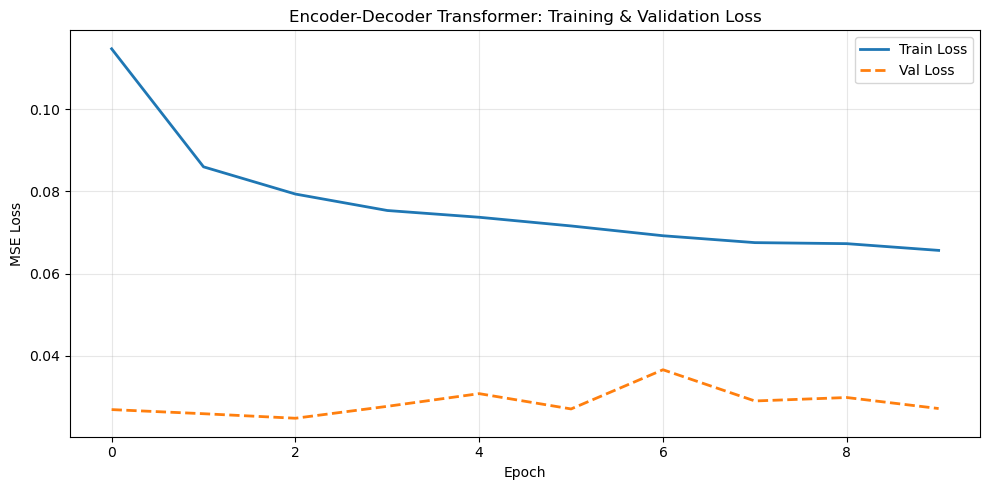

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ed_history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(ed_history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Encoder-Decoder Transformer: Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4 -- Test Evaluation (Autoregressive Inference)

At test time we do **not** have the true future values to feed the decoder. Instead we use **autoregressive inference**:

1. Start with the last known PM2.5 value as the first decoder input token.
2. Run the model to get the prediction for t+1.
3. Append that prediction to the decoder input.
4. Run again to get t+2, and so on.

For efficiency, we can also use teacher forcing at test time (feeding true values) and then compare with autoregressive. Below we implement autoregressive inference.

In [22]:
def autoregressive_inference(model, src, horizon=3):
    """
    Generate multi-step predictions autoregressively.

    Args:
        model: trained EncoderDecoderTransformer
        src: (B, T, n_features) encoder input
        horizon: number of steps to predict

    Returns:
        (B, horizon) predictions
    """
    model.eval()
    B = src.size(0)
    device = src.device

    # Start with the last known PM2.5 value
    last_known = src[:, -1, 0:1]   # (B, 1)
    dec_tokens = [last_known]      # list of (B, 1) tensors

    predictions = []

    for step in range(horizon):
        # Build decoder input: (B, step+1, 1)
        dec_input = torch.stack(dec_tokens, dim=1)  # (B, step+1, 1)

        # Pad to full horizon length for the model
        # We only need up to current step+1, so we pad the rest
        if dec_input.size(1) < horizon:
            pad = torch.zeros(B, horizon - dec_input.size(1), 1, device=device)
            dec_input_padded = torch.cat([dec_input, pad], dim=1)
        else:
            dec_input_padded = dec_input

        with torch.no_grad():
            out = model(src, dec_input_padded)  # (B, horizon)

        # Take prediction at current step
        pred_step = out[:, step]  # (B,)
        predictions.append(pred_step)

        # Feed prediction back as next decoder token
        dec_tokens.append(pred_step.unsqueeze(1))  # (B, 1)

    return torch.stack(predictions, dim=1)  # (B, horizon)

In [23]:
# Evaluate on test set using autoregressive inference
enc_dec_model.eval()
all_preds_ms, all_targets_ms = [], []

for bx, by in test_loader_ms:
    bx = bx.to(device)
    preds = autoregressive_inference(enc_dec_model, bx, horizon=FORECAST_HORIZON)
    all_preds_ms.append(preds.cpu().numpy())
    all_targets_ms.append(by.numpy())

ms_preds   = np.concatenate(all_preds_ms, axis=0)    # (N, 3)
ms_targets = np.concatenate(all_targets_ms, axis=0)   # (N, 3)

# Calculate RMSE and MAE across ALL 3 predicted time steps (flattened)
ms_rmse, ms_mae = calc_metrics(
    ms_targets.flatten(), ms_preds.flatten(), scaler, PM25_IDX
)

print(f'Encoder-Decoder Transformer -- Multi-Step Test Results (across all 3 steps):')
print(f'  RMSE: {ms_rmse:.2f} ug/m3')
print(f'  MAE:  {ms_mae:.2f} ug/m3')
print()

# Per-step breakdown
print('Per-step breakdown:')
for h in range(FORECAST_HORIZON):
    step_rmse, step_mae = calc_metrics(
        ms_targets[:, h], ms_preds[:, h], scaler, PM25_IDX
    )
    print(f'  t+{h+1}: RMSE={step_rmse:.2f}, MAE={step_mae:.2f}')

Encoder-Decoder Transformer -- Multi-Step Test Results (across all 3 steps):
  RMSE: 37.67 ug/m3
  MAE:  20.06 ug/m3

Per-step breakdown:
  t+1: RMSE=23.82, MAE=12.63
  t+2: RMSE=37.68, MAE=20.63
  t+3: RMSE=47.65, MAE=26.92


### Multi-Step Predicted vs. Actual

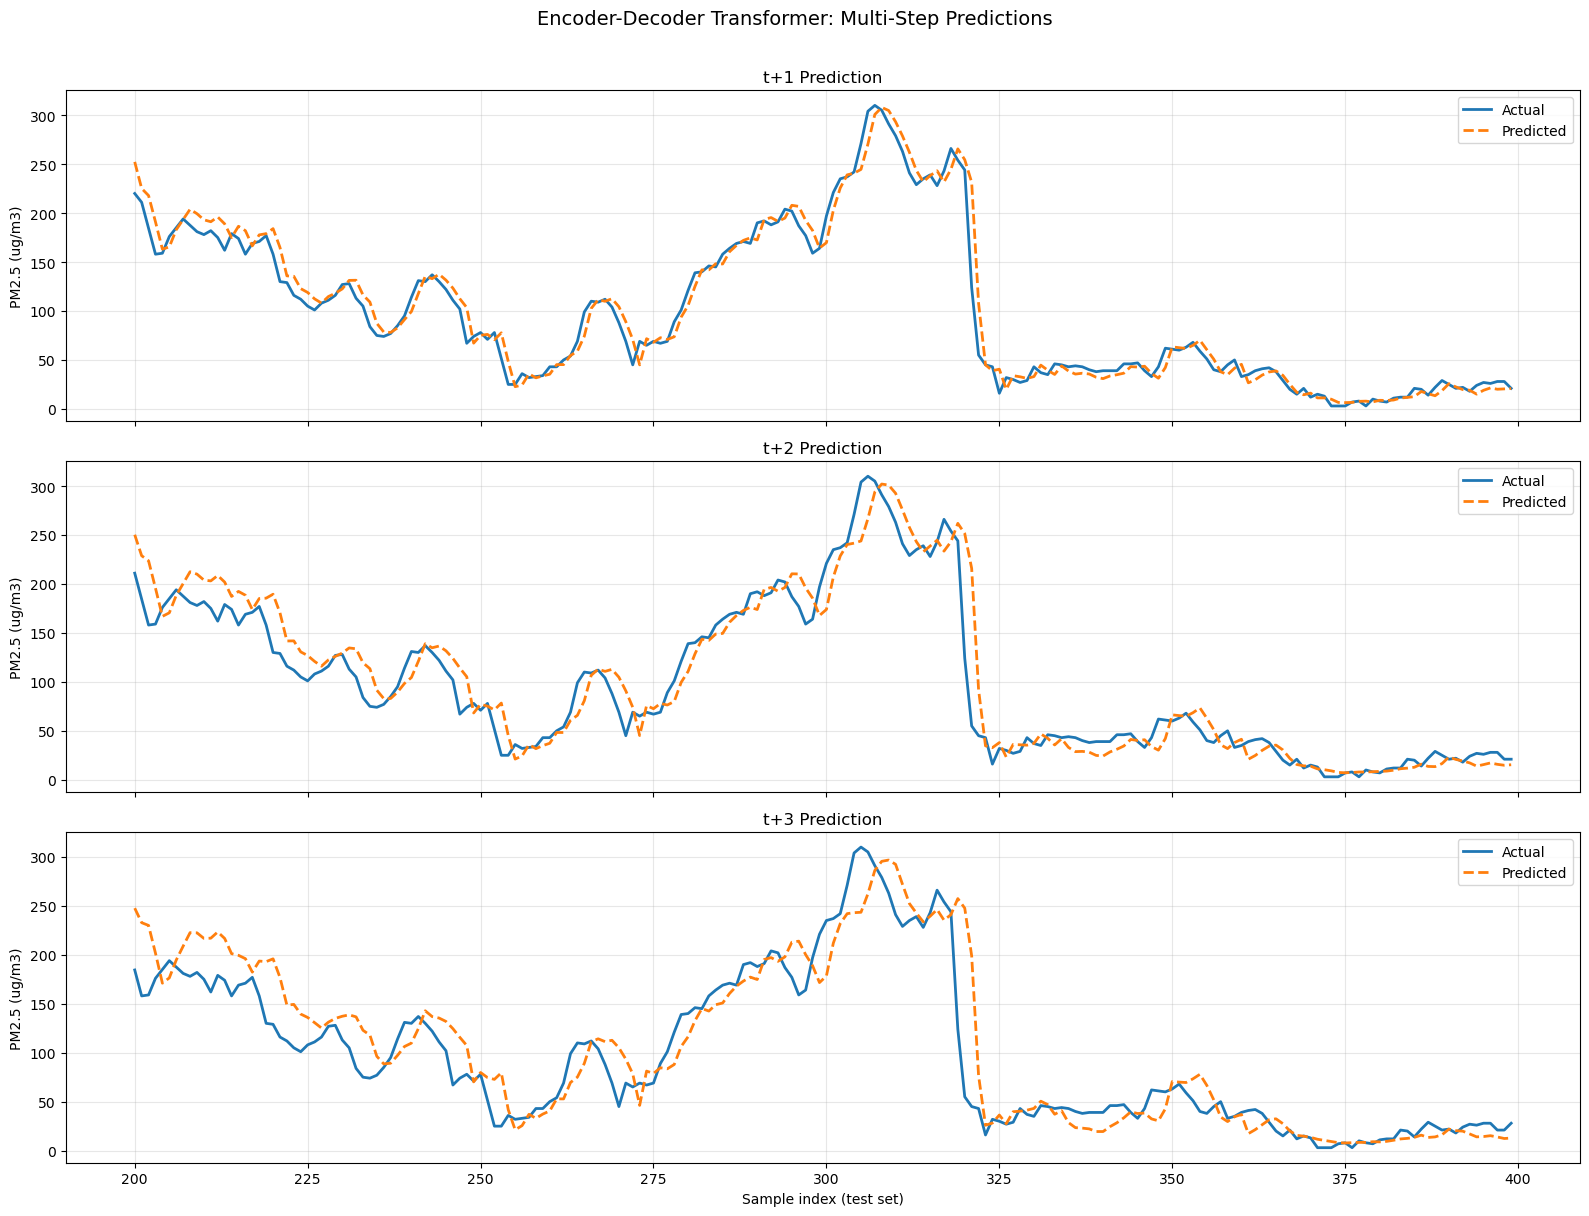

In [24]:
# Plot predictions for each horizon step (first 200 samples)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

start, end = 200, 400
hours = np.arange(start, end)

for h in range(FORECAST_HORIZON):
    # Inverse transform
    d = np.zeros((len(ms_preds), n_f))
    d[:, PM25_IDX] = ms_preds[:, h]
    pred_orig = scaler.inverse_transform(d)[:, PM25_IDX]
    d[:, PM25_IDX] = ms_targets[:, h]
    tgt_orig = scaler.inverse_transform(d)[:, PM25_IDX]

    ax = axes[h]
    ax.plot(hours, tgt_orig[start:end],  label='Actual', linewidth=2)
    ax.plot(hours, pred_orig[start:end], label='Predicted', linewidth=2, linestyle='--')
    ax.set_ylabel('PM2.5 (ug/m3)')
    ax.set_title(f't+{h+1} Prediction')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sample index (test set)')
fig.suptitle('Encoder-Decoder Transformer: Multi-Step Predictions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Part (c): Analysis & Discussion [15 Points]

**Answer the following questions based on your results. Write your responses in markdown cells below each question.**

### 1. Single-Step Comparison
Did the Encoder-only Transformer significantly outperform the simple MLP for the t+1 forecast? If the performance difference is minimal, what characteristics of this specific dataset might make a standard MLP sufficient?


**No, the Encoder-only Transformer did not significantly outperform simple baselines like MLP or Linear Regression.** (In fact, it performed slightly worse than the LSTM, GRU, and Linear Regression from HW3).

A standard MLP (or Linear Regression) is often sufficient for this specific dataset because PM2.5 levels exhibit **very high autocorrelation**. The most critical information for predicting PM2.5 at time $t+1$ is simply the PM2.5 value at time $t$ (or other immediate short-term lags). An MLP can easily assign heavy fixed weights to the most recent time steps, which acts like a strong persistence baseline. In contrast, Transformers are more complex and data-hungry; without large amounts of data to properly learn complex temporal attention patterns, their capacity can lead to overfitting or suboptimal attention compared to simple recent-lag dependence.


### 2. Decoder Cross-Attention
In your Encoder-Decoder architecture, describe exactly what the Cross-Attention mechanism is computing. What serves as the Query (Q), and what serve as the Keys (K) and Values (V)?


In the Encoder-Decoder architecture, the **Cross-Attention mechanism** is where the Decoder extracts necessary historical context from the Encoder.

- **Query (Q):** Comes from the *Decoder* (its current state, representing the sequence of future steps being predicted).
- **Keys (K) and Values (V):** Come from the *Encoder's* final output (the fully encoded historical 24-hour sequence).

Essentially, the cross-attention allows the Decoder at a given future step (Query) to look back at all of the encoded past historical steps (Keys), determine which past steps are most relevant, and pull that information (Values) to help generate the future prediction.


### 3. Autoregressive Inference
During testing (inference), you do not have the true future values to feed into the Decoder. Explain how your model must generate the 3-step forecast in a real-world scenario.


During real-world inference, we must perform **autoregressive decoding** because true future values are unavailable.

The model generates the 3-step forecast sequentially:
1. We start the decoder with the **last known PM2.5 observation** (time $t$) as the initial input.
2. The model uses this and the encoder's context to predict the value for time **$t+1$**.
3. We then **append this prediction** to the decoder input sequence.
4. The model takes the sequence $[y_{t}, \hat{y}_{t+1}]$ to predict the next step, **$t+2$**.
5. We append $\hat{y}_{t+2}$ and repeat the process to predict **$t+3$**.
By feeding its own predictions back as simulated future context, the model steps forward through time.


---
---
# Problem 2: Introduction to Graph Neural Networks (GNNs)

In this problem we build a **Graph Convolutional Network (GCN)** for **node classification** on the **Cora dataset** -- a citation network of machine learning papers.

- **Nodes** = papers (2708 total)
- **Edges** = citations between papers
- **Node features** = bag-of-words of the paper abstract (1433 dimensions)
- **Task** = classify each paper into one of 7 research topics

## Part (a): Dataset Initialization and Exploration [5 Points]

In [25]:
!pip install torch_geometric -q

In [26]:
import sys
!{sys.executable} -m pip install torch_geometric -q


In [27]:
import torch
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid

# Download and load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]

print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [28]:
# Dataset statistics
print('=' * 50)
print('CORA DATASET STATISTICS')
print('=' * 50)
print(f'1. Total number of nodes (papers):    {data.num_nodes}')
print(f'2. Total number of edges (citations): {data.num_edges}')
print(f'3. Node feature dimensionality:       {data.num_node_features}')
print(f'4. Number of classes:                 {dataset.num_classes}')
print()
print(f'Training nodes:   {data.train_mask.sum().item()}')
print(f'Validation nodes: {data.val_mask.sum().item()}')
print(f'Test nodes:       {data.test_mask.sum().item()}')
print()
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self loops:     {data.has_self_loops()}')
print(f'Is undirected:      {data.is_undirected()}')

CORA DATASET STATISTICS
1. Total number of nodes (papers):    2708
2. Total number of edges (citations): 10556
3. Node feature dimensionality:       1433
4. Number of classes:                 7

Training nodes:   140
Validation nodes: 500
Test nodes:       1000

Has isolated nodes: False
Has self loops:     False
Is undirected:      True


---
## Part (b): GNN vs. MLP Implementation [20 Points]

We build two models to compare:
1. **Baseline MLP**: Ignores graph structure entirely, classifies each node based on its own features only.
2. **GCN**: Uses the graph structure (edges) to aggregate information from neighbors via message passing.

### What is message passing?

In a GCN layer, each node updates its representation by:
1. **Aggregating** features from all its neighbors (and itself)
2. **Transforming** the aggregated features through a learned linear layer

The GCN update rule from [Kipf & Welling, 2017](https://arxiv.org/abs/1609.02907):

$$H^{(l+1)} = \sigma\!\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

where $\tilde{A} = A + I$ (adjacency + self-loops), $\tilde{D}$ is the degree matrix, and $W^{(l)}$ is a learnable weight matrix.

### Model 1: Baseline MLP

Architecture: `Linear(1433, 32) -> ReLU -> Dropout -> Linear(32, 7)`

This model treats every paper in isolation -- it only sees the node's own features, not its neighbors.

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    """2-layer MLP for node classification (ignores graph structure)."""
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x     # raw logits (we'll use CrossEntropyLoss which includes softmax)

### Model 2: Graph Convolutional Network (GCN)

Architecture: `GCNConv(1433, 32) -> ReLU -> Dropout -> GCNConv(32, 7)`

`GCNConv` is identical to a linear layer **except** it first aggregates features from neighboring nodes. This means each node's updated representation includes information from its local neighborhood.

In [30]:
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    """2-layer Graph Convolutional Network for node classification."""
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x     # raw logits

In [31]:
# Instantiate both models
HIDDEN_DIM  = 32
NUM_CLASSES = dataset.num_classes
IN_FEATURES = dataset.num_node_features

mlp_model = MLP(IN_FEATURES, HIDDEN_DIM, NUM_CLASSES).to(device)
gcn_model = GCN(IN_FEATURES, HIDDEN_DIM, NUM_CLASSES).to(device)

print(f'MLP parameters: {sum(p.numel() for p in mlp_model.parameters()):,}')
print(f'GCN parameters: {sum(p.numel() for p in gcn_model.parameters()):,}')
print()
print('MLP:')
print(mlp_model)
print()
print('GCN:')
print(gcn_model)

MLP parameters: 46,119
GCN parameters: 46,119

MLP:
MLP(
  (fc1): Linear(in_features=1433, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=7, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

GCN:
GCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
  (dropout): Dropout(p=0.5, inplace=False)
)


---
## Part (c): Training and Evaluation [10 Points]

In [32]:
# Move data to device
data = data.to(device)

In [33]:
def train_gnn(model, data, is_gcn=False, num_epochs=200, lr=0.01):
    """
    Train a node classification model (MLP or GCN) on the Cora dataset.

    Args:
        model: MLP or GCN model
        data: PyG Data object (with train_mask, val_mask, test_mask)
        is_gcn: if True, passes edge_index to model
        num_epochs: number of training epochs
        lr: learning rate

    Returns:
        history dict with train_loss, val_acc lists
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        optimizer.zero_grad()

        if is_gcn:
            out = model(data.x, data.edge_index)   # GCN needs edge_index
        else:
            out = model(data.x)                     # MLP only needs features

        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        # --- Validation accuracy ---
        model.eval()
        with torch.no_grad():
            if is_gcn:
                out = model(data.x, data.edge_index)
            else:
                out = model(data.x)
            pred = out.argmax(dim=1)
            val_correct = (pred[data.val_mask] == data.y[data.val_mask]).sum().item()
            val_acc = val_correct / data.val_mask.sum().item()
            history['val_acc'].append(val_acc)

        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {loss.item():.4f}  Val Acc: {val_acc:.4f}')

    return history

In [34]:
# Train MLP
torch.manual_seed(42)
mlp_model = MLP(IN_FEATURES, HIDDEN_DIM, NUM_CLASSES).to(device)

print('Training MLP (no graph structure)')
print('=' * 50)
mlp_history = train_gnn(mlp_model, data, is_gcn=False, num_epochs=200, lr=0.01)

Training MLP (no graph structure)


Epoch [  1/200]  Loss: 1.9501  Val Acc: 0.1220


Epoch [ 50/200]  Loss: 0.5868  Val Acc: 0.5640


Epoch [100/200]  Loss: 0.2424  Val Acc: 0.5680


Epoch [150/200]  Loss: 0.2061  Val Acc: 0.5660


Epoch [200/200]  Loss: 0.1767  Val Acc: 0.5700


In [35]:
# Train GCN
torch.manual_seed(42)
gcn_model = GCN(IN_FEATURES, HIDDEN_DIM, NUM_CLASSES).to(device)

print('Training GCN (with graph structure)')
print('=' * 50)
gcn_history = train_gnn(gcn_model, data, is_gcn=True, num_epochs=200, lr=0.01)

Training GCN (with graph structure)


Epoch [  1/200]  Loss: 1.9466  Val Acc: 0.2520


Epoch [ 50/200]  Loss: 0.7523  Val Acc: 0.7960


Epoch [100/200]  Loss: 0.3384  Val Acc: 0.7940


Epoch [150/200]  Loss: 0.2653  Val Acc: 0.7900


Epoch [200/200]  Loss: 0.2238  Val Acc: 0.7960


### Validation Accuracy Curves

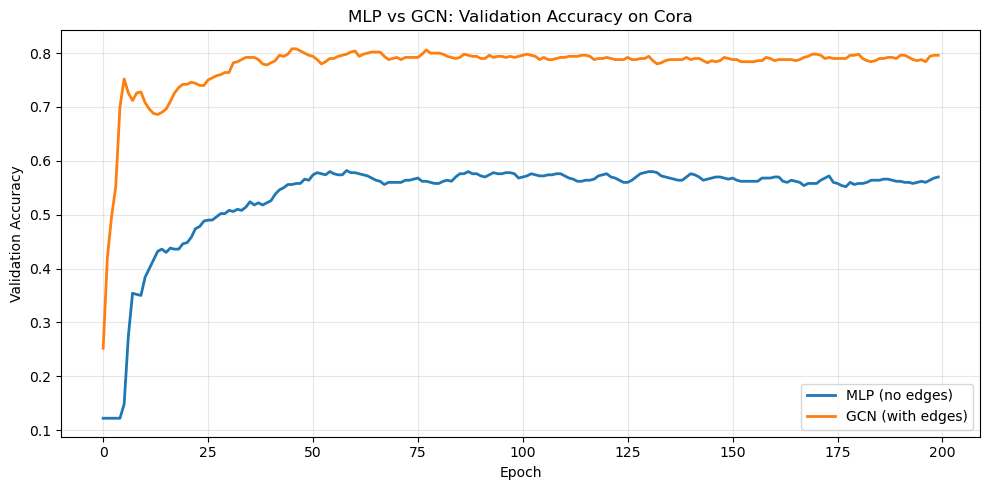

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_history['val_acc'], label='MLP (no edges)', linewidth=2)
ax.plot(gcn_history['val_acc'], label='GCN (with edges)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('MLP vs GCN: Validation Accuracy on Cora')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Test Accuracy

In [37]:
def test_accuracy(model, data, is_gcn=False):
    """Compute test accuracy."""
    model.eval()
    with torch.no_grad():
        if is_gcn:
            out = model(data.x, data.edge_index)
        else:
            out = model(data.x)
        pred = out.argmax(dim=1)
        correct = (pred[data.test_mask] == data.y[data.test_mask]).sum().item()
        acc = correct / data.test_mask.sum().item()
    return acc

mlp_test_acc = test_accuracy(mlp_model, data, is_gcn=False)
gcn_test_acc = test_accuracy(gcn_model, data, is_gcn=True)

print('=' * 50)
print('FINAL TEST ACCURACY')
print('=' * 50)
print(f'MLP (no graph):      {mlp_test_acc:.4f} ({mlp_test_acc*100:.1f}%)')
print(f'GCN (with graph):    {gcn_test_acc:.4f} ({gcn_test_acc*100:.1f}%)')
print(f'Improvement:         {(gcn_test_acc - mlp_test_acc)*100:.1f} percentage points')

FINAL TEST ACCURACY
MLP (no graph):      0.5690 (56.9%)
GCN (with graph):    0.8060 (80.6%)
Improvement:         23.7 percentage points


### Discussion

**Briefly discuss the difference in performance between MLP and GCN. Explain specifically how the message-passing mechanism of the GCN leads to this difference.**

## GCN vs MLP
1. **GCN significantly outperforms the baseline MLP**: 
The key difference in performance between a standard Multi-Layer Perceptron (MLP) and a Graph Convolutional Network (GCN) on a dataset like Cora comes down to how they handle context. The difference in Performance For node classification tasks like the Cora dataset (predicting paper topics), a GCN significantly outperforms an MLP (often achieving ~80-82% test accuracy, compared to ~55-60% for a standard MLP).

## Why does message-passing lead to this difference?

1. **MLPs operate in isolation:** An MLP only looks at the features of a single node (e.g., the bag-of-words representation of one paper) to make a prediction. It completely ignores that papers are connected. If a paper's text is ambiguous, the MLP has to guess.

2. **GCNs use message-passing (Neighborhood Aggregation):** 
A GCN utilizes the edges in the graph (citations). During a message-passing step, each node aggregates the feature vectors of its direct neighbors and combines them with its own features.

3. **Exploiting Homophily:** 
Citation networks exhibit strong homophily—papers tend to cite other papers in the exact same field. By averaging or aggregating neighborhood features, the message-passing mechanism essentially "smooths" the features locally. Even if a specific paper lacks strong keyword indicators for "Reinforcement Learning," if all the papers it cites (and that cite it) are about Reinforcement Learning, the aggregated message will strongly reflect that topic.

In short, the message-passing mechanism allows the GCN to dynamically borrow rich, contextual information from its neighbors, whereas an MLP is entirely blind to the graph structure.

This dramatic improvement is due to the **message-passing mechanism** of the GCN. While the MLP treats each citation network node (paper) in complete isolation using only its own word features, the GCN leverages the graph structure. Through message-passing, each node aggregates the feature representations of its neighbors (cited or citing papers). In citation networks like Cora, there is strict homophily—papers almost exclusively cite other papers within the same research topic. By smoothing the node features with the neighborhood context, the GCN creates a much richer representation that inherently encodes community structure, making classification vastly more accurate than relying on the text of a single paper alone.
